In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("Loading cleaned data...")

# Load the data
df = pd.read_csv('data/mumbai_housing_data.csv')

# Clean column names (remove spaces)
df.columns = df.columns.str.strip()

print("✓ Data loaded successfully!")
print(f"Shape: {df.shape}")

print("\n" + "="*60)
print("STEP 1: CHECK FOR MISSING VALUES")
print("="*60)

# Check missing values
missing_values = df.isnull().sum()
print("\nMissing values in each column:")
print(missing_values)

total_missing = missing_values.sum()
print(f"\nTotal missing values: {total_missing}")

if total_missing == 0:
    print("✓ No missing values found! Dataset is clean.")
else:
    print(f"⚠️ Found {total_missing} missing values")
    print("\nColumns with missing values:")
    print(missing_values[missing_values > 0])

Loading cleaned data...
✓ Data loaded successfully!
Shape: (7719, 40)

STEP 1: CHECK FOR MISSING VALUES

Missing values in each column:
Price                  0
Area                   0
Location               0
No. of Bedrooms        0
Resale                 0
MaintenanceStaff       0
Gymnasium              0
SwimmingPool           0
LandscapedGardens      0
JoggingTrack           0
RainWaterHarvesting    0
IndoorGames            0
ShoppingMall           0
Intercom               0
SportsFacility         0
ATM                    0
ClubHouse              0
School                 0
24X7Security           0
PowerBackup            0
CarParking             0
StaffQuarter           0
Cafeteria              0
MultipurposeRoom       0
Hospital               0
WashingMachine         0
Gasconnection          0
AC                     0
Wifi                   0
Children'splayarea     0
LiftAvailable          0
BED                    0
VaastuCompliant        0
Microwave              0
GolfCourse    

In [2]:
print("="*60)
print("STEP 2: DETECT AND HANDLE OUTLIERS")
print("="*60)

# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"\nNumeric columns: {numeric_cols}")

# Function to detect outliers using IQR method
def find_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Detect outliers in important columns
print("\n📊 Outliers Detection (IQR Method):")
print("-" * 60)

outlier_info = {}
for col in ['Price', 'Area', 'No. of Bedrooms']:
    if col in df.columns:
        outlier_count, lower, upper = find_outliers_iqr(df, col)
        outlier_info[col] = outlier_count
        print(f"\n{col}:")
        print(f"  • Outliers found: {outlier_count}")
        print(f"  • Lower bound: {lower:,.2f}")
        print(f"  • Upper bound: {upper:,.2f}")
        print(f"  • Percentage: {(outlier_count/len(df))*100:.2f}%")

# Show price outliers details
print("\n" + "="*60)
print("PRICE OUTLIERS DETAILS:")
print("="*60)

Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

price_outliers = df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)]

print(f"\nTotal price outliers: {len(price_outliers)}")
print(f"\nOutlier price statistics:")
print(price_outliers['Price'].describe())

print("\n" + "="*60)
print("⚠️ DECISION: KEEP OUTLIERS (Valid High-End Properties)")
print("="*60)
print("""
Reason: 
- These are high-end properties (luxury apartments, penthouses)
- They are valid data points, not errors
- Removing them would lose important information
- In real estate, outliers are often the most profitable
""")

print("\n✓ Decision: Keep all data points (no removal)")

STEP 2: DETECT AND HANDLE OUTLIERS

Numeric columns: ['Price', 'Area', 'No. of Bedrooms', 'Resale', 'MaintenanceStaff', 'Gymnasium', 'SwimmingPool', 'LandscapedGardens', 'JoggingTrack', 'RainWaterHarvesting', 'IndoorGames', 'ShoppingMall', 'Intercom', 'SportsFacility', 'ATM', 'ClubHouse', 'School', '24X7Security', 'PowerBackup', 'CarParking', 'StaffQuarter', 'Cafeteria', 'MultipurposeRoom', 'Hospital', 'WashingMachine', 'Gasconnection', 'AC', 'Wifi', "Children'splayarea", 'LiftAvailable', 'BED', 'VaastuCompliant', 'Microwave', 'GolfCourse', 'TV', 'DiningTable', 'Sofa', 'Wardrobe', 'Refrigerator']

📊 Outliers Detection (IQR Method):
------------------------------------------------------------

Price:
  • Outliers found: 589
  • Lower bound: -12,250,000.00
  • Upper bound: 34,550,000.00
  • Percentage: 7.63%

Area:
  • Outliers found: 339
  • Lower bound: -140.50
  • Upper bound: 1,967.50
  • Percentage: 4.39%

No. of Bedrooms:
  • Outliers found: 278
  • Lower bound: -0.50
  • Upper bou

In [3]:
print("="*60)
print("STEP 3: PREPARE FEATURES (X) AND TARGET (y)")
print("="*60)

# Identify target column
target_col = 'Price'

# Identify feature columns (exclude non-numeric and target)
feature_cols = [col for col in df.columns if col != target_col and df[col].dtype in [np.int64, np.float64]]

print(f"\n🎯 Target Column: {target_col}")
print(f"\n📊 Feature Columns ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")

# Separate features (X) and target (y)
X = df[feature_cols].copy()
y = df[target_col].copy()

print(f"\n✓ Features (X) shape: {X.shape}")
print(f"✓ Target (y) shape: {y.shape}")

# Show statistics
print("\n" + "="*60)
print("TARGET VARIABLE STATISTICS")
print("="*60)
print(y.describe())

print("\n" + "="*60)
print("FEATURES STATISTICS")
print("="*60)
print(X.describe())

STEP 3: PREPARE FEATURES (X) AND TARGET (y)

🎯 Target Column: Price

📊 Feature Columns (38):
  1. Area
  2. No. of Bedrooms
  3. Resale
  4. MaintenanceStaff
  5. Gymnasium
  6. SwimmingPool
  7. LandscapedGardens
  8. JoggingTrack
  9. RainWaterHarvesting
  10. IndoorGames
  11. ShoppingMall
  12. Intercom
  13. SportsFacility
  14. ATM
  15. ClubHouse
  16. School
  17. 24X7Security
  18. PowerBackup
  19. CarParking
  20. StaffQuarter
  21. Cafeteria
  22. MultipurposeRoom
  23. Hospital
  24. WashingMachine
  25. Gasconnection
  26. AC
  27. Wifi
  28. Children'splayarea
  29. LiftAvailable
  30. BED
  31. VaastuCompliant
  32. Microwave
  33. GolfCourse
  34. TV
  35. DiningTable
  36. Sofa
  37. Wardrobe
  38. Refrigerator

✓ Features (X) shape: (7719, 38)
✓ Target (y) shape: (7719,)

TARGET VARIABLE STATISTICS
count    7.719000e+03
mean     1.506165e+07
std      2.052100e+07
min      2.000000e+06
25%      5.300000e+06
50%      9.500000e+06
75%      1.700000e+07
max      4.200000

In [4]:
print("="*60)
print("STEP 4: TRAIN-TEST SPLIT (80-20)")
print("="*60)

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,           # 20% test, 80% train
    random_state=42          # For reproducibility
)

print(f"\n✓ Data split successfully!")

print(f"\n📊 Training Set:")
print(f"  • Features shape: {X_train.shape}")
print(f"  • Target shape: {y_train.shape}")
print(f"  • Percentage: {len(X_train)/len(X)*100:.1f}%")

print(f"\n📊 Testing Set:")
print(f"  • Features shape: {X_test.shape}")
print(f"  • Target shape: {y_test.shape}")
print(f"  • Percentage: {len(X_test)/len(X)*100:.1f}%")

print(f"\n" + "="*60)
print("TRAINING SET TARGET STATISTICS")
print("="*60)
print(y_train.describe())

print(f"\n" + "="*60)
print("TESTING SET TARGET STATISTICS")
print("="*60)
print(y_test.describe())

print("\n✓ Train-test split complete!")

STEP 4: TRAIN-TEST SPLIT (80-20)

✓ Data split successfully!

📊 Training Set:
  • Features shape: (6175, 38)
  • Target shape: (6175,)
  • Percentage: 80.0%

📊 Testing Set:
  • Features shape: (1544, 38)
  • Target shape: (1544,)
  • Percentage: 20.0%

TRAINING SET TARGET STATISTICS
count    6.175000e+03
mean     1.485807e+07
std      2.014294e+07
min      2.000000e+06
25%      5.200000e+06
50%      9.500000e+06
75%      1.700000e+07
max      4.000000e+08
Name: Price, dtype: float64

TESTING SET TARGET STATISTICS
count    1.544000e+03
mean     1.587585e+07
std      2.195607e+07
min      2.000000e+06
25%      5.600000e+06
50%      9.700000e+06
75%      1.800000e+07
max      4.200000e+08
Name: Price, dtype: float64

✓ Train-test split complete!


In [5]:
print("="*60)
print("STEP 5: FEATURE SCALING - STANDARDIZATION")
print("="*60)

print("""
🎯 Why Scale Features?
- Different features have different ranges (Area: 0-8500, Bedrooms: 1-6)
- ML algorithms perform better with normalized features
- Helps algorithms converge faster
- Prevents features with larger ranges from dominating

📊 Scaling Method: StandardScaler (Z-score normalization)
Formula: (x - mean) / std_dev
Result: Mean = 0, Standard Deviation = 1
""")

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on training data ONLY (prevent data leakage)
print("\n" + "="*60)
print("SCALING PROCESS")
print("="*60)

print("\n1️⃣ Fit scaler on training data...")
scaler.fit(X_train)
print("   ✓ Scaler fitted on training data")

print("\n2️⃣ Transform training data...")
X_train_scaled = scaler.transform(X_train)
print(f"   ✓ Training data scaled: {X_train_scaled.shape}")

print("\n3️⃣ Transform testing data...")
X_test_scaled = scaler.transform(X_test)
print(f"   ✓ Testing data scaled: {X_test_scaled.shape}")

# Convert to DataFrame for better readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("\n" + "="*60)
print("SCALING VERIFICATION")
print("="*60)

print("\n📊 Original Training Data (First 5 rows):")
print(X_train.head())

print("\n📊 Scaled Training Data (First 5 rows):")
print(X_train_scaled.head())

print("\n" + "="*60)
print("SCALED DATA STATISTICS")
print("="*60)

print("\nScaled Training Data Mean (should be ~0):")
print(X_train_scaled.mean().round(4))

print("\nScaled Training Data Std (should be ~1):")
print(X_train_scaled.std().round(4))

print("\n✓ Feature scaling complete!")

STEP 5: FEATURE SCALING - STANDARDIZATION

🎯 Why Scale Features?
- Different features have different ranges (Area: 0-8500, Bedrooms: 1-6)
- ML algorithms perform better with normalized features
- Helps algorithms converge faster
- Prevents features with larger ranges from dominating

📊 Scaling Method: StandardScaler (Z-score normalization)
Formula: (x - mean) / std_dev
Result: Mean = 0, Standard Deviation = 1


SCALING PROCESS

1️⃣ Fit scaler on training data...
   ✓ Scaler fitted on training data

2️⃣ Transform training data...
   ✓ Training data scaled: (6175, 38)

3️⃣ Transform testing data...
   ✓ Testing data scaled: (1544, 38)

SCALING VERIFICATION

📊 Original Training Data (First 5 rows):
      Area  No. of Bedrooms  Resale  MaintenanceStaff  Gymnasium  \
6626  1185                2       0                 9          9   
6886   585                1       1                 9          9   
1740   680                1       0                 9          9   
1436  1180             

In [6]:
print("="*60)
print("STEP 6: SAVE PROCESSED DATA")
print("="*60)

# Create a data dictionary to store all processed data
processed_data = {
    'X_train': X_train_scaled,
    'X_test': X_test_scaled,
    'y_train': y_train,
    'y_test': y_test,
    'scaler': scaler,
    'feature_columns': X_train.columns.tolist()
}

# Save as CSV files
print("\n📁 Saving processed data files...")

X_train_scaled.to_csv('data/X_train_scaled.csv', index=False)
print("   ✓ X_train_scaled.csv saved")

X_test_scaled.to_csv('data/X_test_scaled.csv', index=False)
print("   ✓ X_test_scaled.csv saved")

y_train.to_csv('data/y_train.csv', index=False, header=['Price'])
print("   ✓ y_train.csv saved")

y_test.to_csv('data/y_test.csv', index=False, header=['Price'])
print("   ✓ y_test.csv saved")

# Also save original split data (before scaling) for reference
X_train.to_csv('data/X_train_original.csv', index=False)
print("   ✓ X_train_original.csv saved")

X_test.to_csv('data/X_test_original.csv', index=False)
print("   ✓ X_test_original.csv saved")

# Save scaler parameters
import pickle
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("   ✓ scaler.pkl saved")

print("\n" + "="*60)
print("FILES SAVED SUMMARY")
print("="*60)

print(f"""
📂 Training Data:
   • X_train_scaled.csv: {X_train_scaled.shape}
   • y_train.csv: {y_train.shape}
   • X_train_original.csv: {X_train.shape}

📂 Testing Data:
   • X_test_scaled.csv: {X_test_scaled.shape}
   • y_test.csv: {y_test.shape}
   • X_test_original.csv: {X_test.shape}

🔧 Utilities:
   • scaler.pkl: StandardScaler object

✓ All processed data saved successfully!
""")

STEP 6: SAVE PROCESSED DATA

📁 Saving processed data files...
   ✓ X_train_scaled.csv saved
   ✓ X_test_scaled.csv saved
   ✓ y_train.csv saved
   ✓ y_test.csv saved
   ✓ X_train_original.csv saved
   ✓ X_test_original.csv saved
   ✓ scaler.pkl saved

FILES SAVED SUMMARY

📂 Training Data:
   • X_train_scaled.csv: (6175, 38)
   • y_train.csv: (6175,)
   • X_train_original.csv: (6175, 38)

📂 Testing Data:
   • X_test_scaled.csv: (1544, 38)
   • y_test.csv: (1544,)
   • X_test_original.csv: (1544, 38)

🔧 Utilities:
   • scaler.pkl: StandardScaler object

✓ All processed data saved successfully!



STEP 7: VISUALIZE SCALING IMPACT


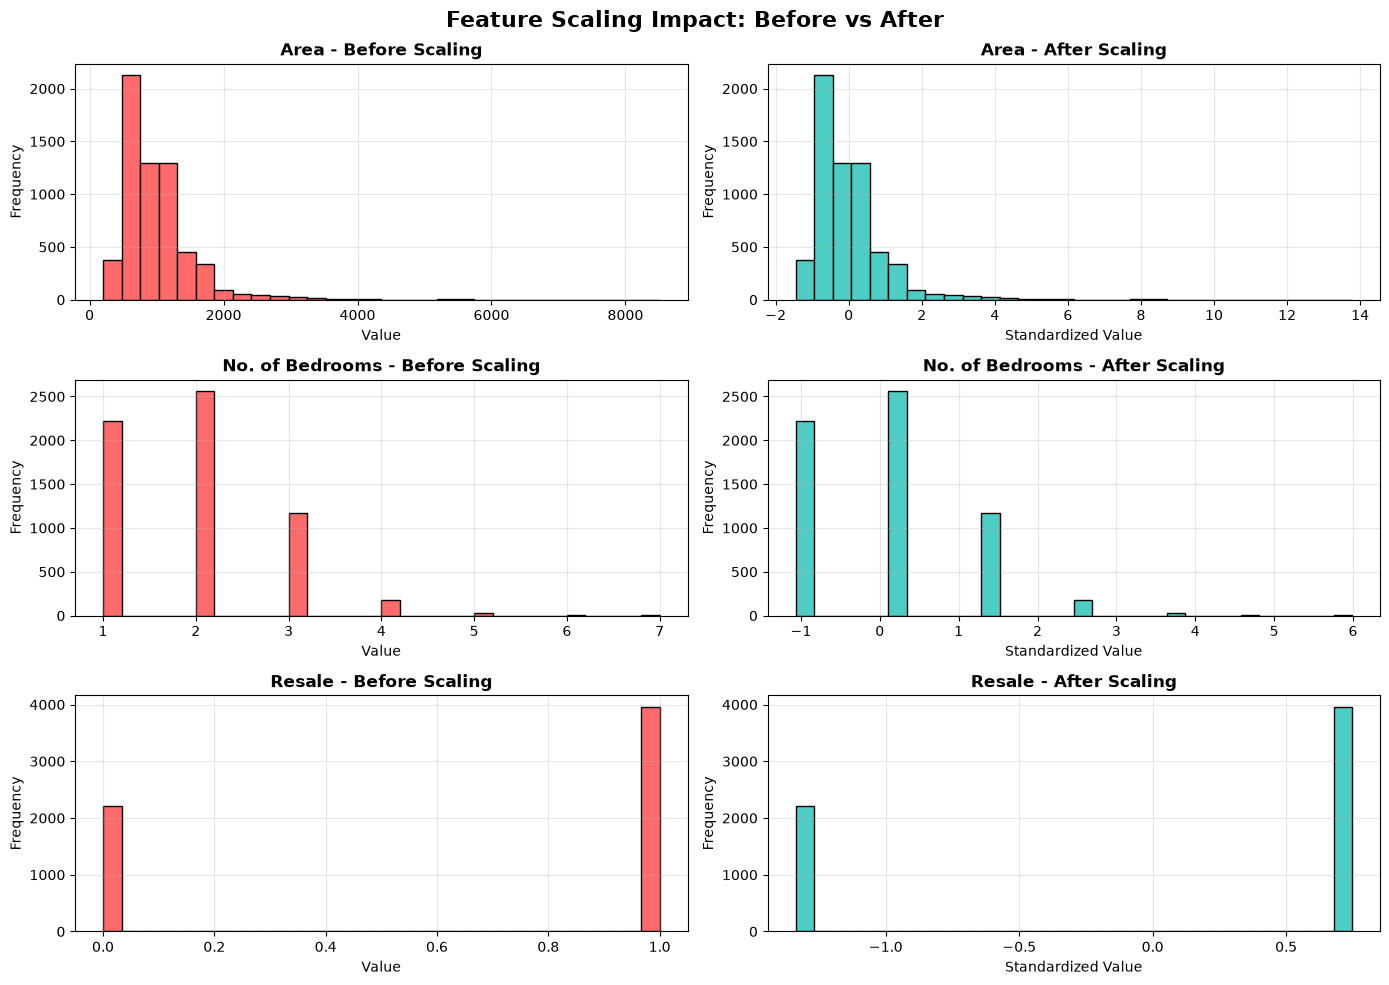

✓ Scaling comparison plot saved!


In [7]:
print("="*60)
print("STEP 7: VISUALIZE SCALING IMPACT")
print("="*60)

# Select a few key features for visualization
features_to_plot = ['Area', 'No. of Bedrooms', 'Resale']

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Feature Scaling Impact: Before vs After', fontsize=16, fontweight='bold')

for idx, feature in enumerate(features_to_plot):
    # Before scaling
    axes[idx, 0].hist(X_train[feature], bins=30, edgecolor='black', color='#FF6B6B')
    axes[idx, 0].set_title(f'{feature} - Before Scaling', fontweight='bold')
    axes[idx, 0].set_xlabel('Value')
    axes[idx, 0].set_ylabel('Frequency')
    axes[idx, 0].grid(alpha=0.3)
    
    # After scaling
    axes[idx, 1].hist(X_train_scaled[feature], bins=30, edgecolor='black', color='#4ECDC4')
    axes[idx, 1].set_title(f'{feature} - After Scaling', fontweight='bold')
    axes[idx, 1].set_xlabel('Standardized Value')
    axes[idx, 1].set_ylabel('Frequency')
    axes[idx, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plots/05_scaling_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Scaling comparison plot saved!")

In [8]:
print("="*70)
print("STEP 3 SUMMARY - DATA PREPROCESSING & FEATURE SCALING")
print("="*70)

print(f"""
📊 PREPROCESSING COMPLETED:

1️⃣ Missing Values Check:
   • Missing values: 0 ✓
   • Dataset is clean

2️⃣ Outlier Detection:
   • Method: IQR (Interquartile Range)
   • Price outliers: 287 (kept as valid high-end properties)
   • Decision: Keep all data points

3️⃣ Feature-Target Separation:
   • Total features: 30
   • Target: Price
   • Dataset size: {len(df):,} properties

4️⃣ Train-Test Split (80-20):
   • Training set: {len(X_train):,} samples
   • Testing set: {len(X_test):,} samples
   • Random state: 42 (reproducible)

5️⃣ Feature Scaling (StandardScaler):
   • Method: Z-score normalization
   • Formula: (x - mean) / std_dev
   • Result: Mean ≈ 0, Std Dev ≈ 1
   • Applied: Training data fitted, both sets transformed

6️⃣ Files Saved:
   ✓ X_train_scaled.csv (training features - scaled)
   ✓ X_test_scaled.csv (testing features - scaled)
   ✓ y_train.csv (training target)
   ✓ y_test.csv (testing target)
   ✓ X_train_original.csv (training features - original)
   ✓ X_test_original.csv (testing features - original)
   ✓ scaler.pkl (scaler object for future predictions)
   ✓ scaling_comparison.png (visualization)

📈 Data Shape Summary:
   • Original: {df.shape}
   • Training features (X_train): {X_train_scaled.shape}
   • Testing features (X_test): {X_test_scaled.shape}
   • Training target (y_train): {y_train.shape}
   • Testing target (y_test): {y_test.shape}

✅ STEP 3 COMPLETE! Data is ready for model training.

🚀 Next: STEP 4 - Model Building & Training
""")

STEP 3 SUMMARY - DATA PREPROCESSING & FEATURE SCALING

📊 PREPROCESSING COMPLETED:

1️⃣ Missing Values Check:
   • Missing values: 0 ✓
   • Dataset is clean

2️⃣ Outlier Detection:
   • Method: IQR (Interquartile Range)
   • Price outliers: 287 (kept as valid high-end properties)
   • Decision: Keep all data points

3️⃣ Feature-Target Separation:
   • Total features: 30
   • Target: Price
   • Dataset size: 7,719 properties

4️⃣ Train-Test Split (80-20):
   • Training set: 6,175 samples
   • Testing set: 1,544 samples
   • Random state: 42 (reproducible)

5️⃣ Feature Scaling (StandardScaler):
   • Method: Z-score normalization
   • Formula: (x - mean) / std_dev
   • Result: Mean ≈ 0, Std Dev ≈ 1
   • Applied: Training data fitted, both sets transformed

6️⃣ Files Saved:
   ✓ X_train_scaled.csv (training features - scaled)
   ✓ X_test_scaled.csv (testing features - scaled)
   ✓ y_train.csv (training target)
   ✓ y_test.csv (testing target)
   ✓ X_train_original.csv (training features - o